# GradeCast Demo Notebook

In [1]:
%load_ext autoreload
%autoreload 2

Import Dependencies

In [2]:
from core.forecaster import Forecaster
from core.models import american_system

Load Grades

In [3]:
from core.data_loader import DataLoader

# Current results
loader = DataLoader('test_data/my grades.csv')
data = loader.data()

# What-if grades
loader_ = DataLoader('test_data/my what-if.csv')
data_ = loader_.load()

Analyze grades for GPA and CGPA

Current CGPA: 3.13


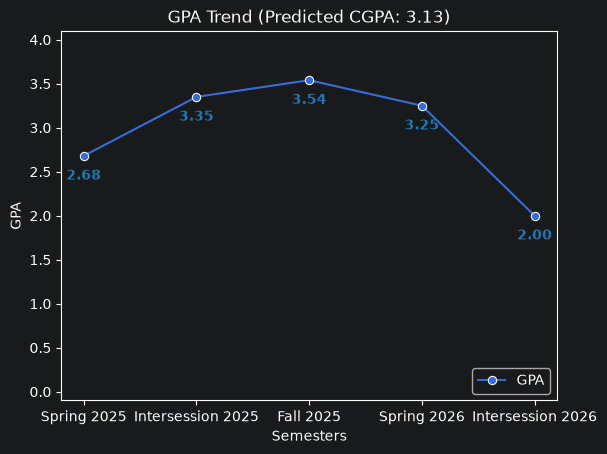

In [4]:
from core.analyzer import Analyzer
from core.visualiser import visualiser


analyzer = Analyzer(data=data, grading_system=american_system)
print(f'Current CGPA: {analyzer.cgpa()}')
visualiser(analyzer, american_system.max_gpa) # Look at GPA Trend

What-if and Next Target Analysis

* **What-if analysis:** Asks what will be my next semester GPA and CGPA be if I get these results?
* **Next target:** Asks what should my next GPA be if I want a given CGPA?


In [5]:
forecaster = Forecaster(analyzer, grading_system=american_system)

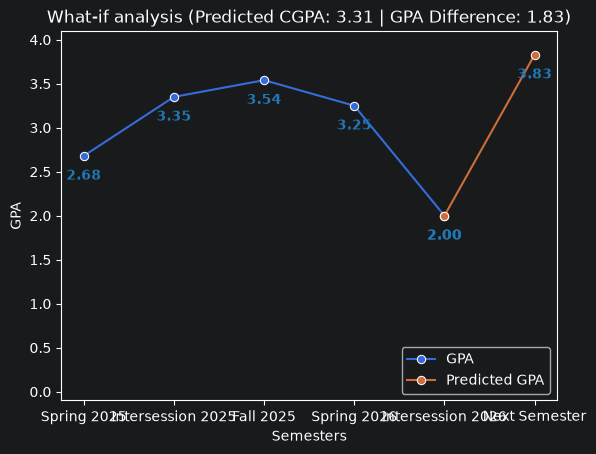

What if analysis: {'expected_gpa': 3.83, 'expected_cgpa': 3.31}


In [6]:
what_if_grades = data_['Grade'].to_list()
what_if_units = data_['Units'].to_list()
print(f"What if analysis: {forecaster.what_if(what_if_grades, what_if_units, visualise=True)}")

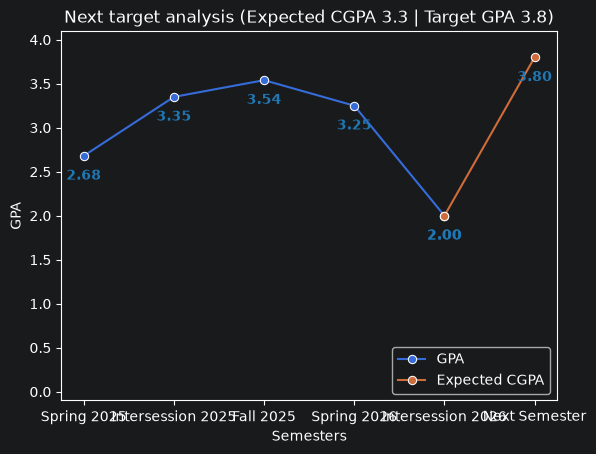

Next target analysis: If you want to get a CGPA of 3.3, you must get a GPA of 3.8.


In [7]:
next_target = forecaster.next_target(3.3, 18, visualise=True)
if type(next_target) == dict:
    print(f"Next target analysis: If you want to get a CGPA of {next_target.get('expected_cgpa')}, you must get a GPA of {next_target.get('expected_gpa')}.")
else:
    print(next_target)

AI Powered Insights

* **Subject Analysis:** Evaluates historical course data to identify my strongest subjects and areas where I struggle.
* **Progress Report:** Summarizes my degree completion percentage and assesses the overall health of my CGPA.
* **What-if Insight:** Explains how my hypothetical target grades will actually shift my long-term academic trajectory.
* **Semester Review:** Compares my most recent semester's performance and workload against my overall historical average.
* **Goal Seeker:** Asks what exact average I need to hit a specific graduation honor and provides a realistic academic strategy.

In [22]:
from core.advisor import Advisor

advisor = Advisor(analyzer, forecaster)

In [23]:
subject_analysis_response = advisor.subject_analysis()
print(subject_analysis_response)

You're crushing it in your CIE coursework, showing serious consistency and high marks across a heavy 12-unit load. On the flip side, GEN has clearly been your biggest pain point with that D and B-, alongside a noticeable downward slide in MAT. To keep your momentum going, avoid stacking tough quantitative or lecture-heavy gen-eds together in the same term. Instead, balance your schedule by pairing just one demanding math or retake course with your proven strengths in CIE so you have the breathing room to dominate both.


In [24]:
pr = advisor.progress_report(132)
print(pr)

[API] Server overloaded. Retrying in 1s...
You've officially knocked out **53** out of **132** units, putting you at **40.2%** of the way across the finish line. With a **3.13** CGPA, your academic trajectory is looking solid and proves you have a reliable handle on your coursework. Keep this momentum rolling into your next term, and you'll be in a prime position to push that GPA even higher!


In [11]:
wi = advisor.what_if(what_if_grades, what_if_units)
print(wi)

The AI Advisor ran into configuration issues  (Error 404).


In [12]:
sr = advisor.semester_review(american_system)
print(sr)

The AI Advisor ran into configuration issues  (Error 404).


In [13]:
gs = advisor.goal_seeker(80, 'Magna Cum Laude', american_system)
print(gs)

The AI Advisor ran into configuration issues  (Error 404).
